In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
print(sys.executable)
import yfinance as yf
from datetime import datetime
print("Everything works!")


tickers = ["TSLA", "SPY", "BND"]

start_date = "2015-01-01"
end_date = "2026-06-30"

#Download 

data = {}

for ticker in tickers:
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True
    )
    
    df["Ticker"] = ticker
    data[ticker] = df
    data["TSLA"].head()

combined = pd.concat(data.values())
combined.head()
combined = combined.reset_index()
combined.to_csv("../data/processed/stock_data.csv", index=False)



c:\Users\Test\PycharmProjects\portfolio-optimization\venv\Scripts\python.exe
Everything works!


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


<class 'pandas.DataFrame'>
RangeIndex: 8665 entries, 0 to 8664
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      8664 non-null   str  
 1   Close     2889 non-null   str  
 2   High      2889 non-null   str  
 3   Low       2889 non-null   str  
 4   Open      2889 non-null   str  
 5   Volume    2889 non-null   str  
 6   Ticker    8664 non-null   str  
 7   Close.1   2889 non-null   str  
 8   High.1    2889 non-null   str  
 9   Low.1     2889 non-null   str  
 10  Open.1    2889 non-null   str  
 11  Volume.1  2889 non-null   str  
 12  Close.2   2889 non-null   str  
 13  High.2    2889 non-null   str  
 14  Low.2     2889 non-null   str  
 15  Open.2    2889 non-null   str  
 16  Volume.2  2889 non-null   str  
dtypes: str(17)
memory usage: 1.1 MB


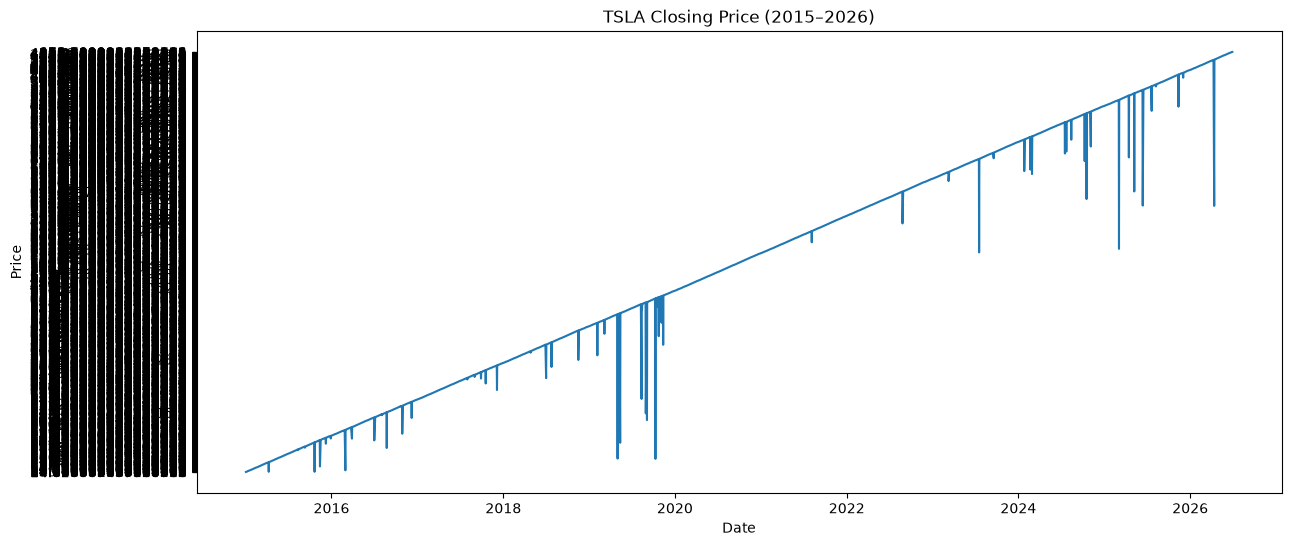

In [25]:
df = pd.read_csv("../data/processed/stock_data.csv")

df.head()
df.info()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.isnull().sum()
df = df.ffill()
df.describe()

#stock price over time 

import matplotlib.pyplot as plt

tsla = df[df["Ticker"] == "TSLA"]

plt.figure(figsize=(14,6))
plt.plot(tsla["Date"], tsla["Close"])
plt.title("TSLA Closing Price (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


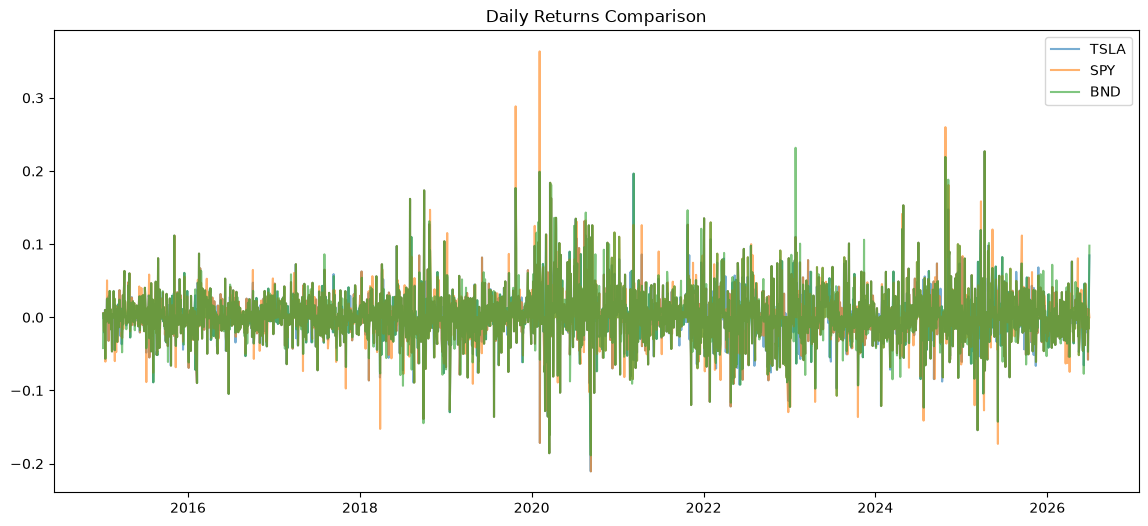

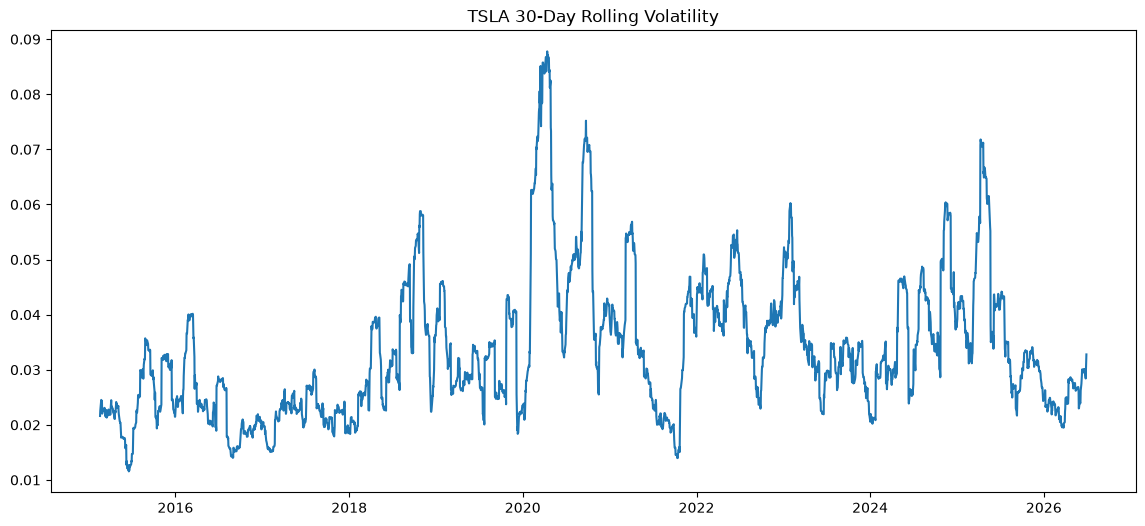

In [26]:
#Daily Returns + Volatility Analysis

df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
cols = ["Open", "High", "Low", "Close", "Volume"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()
df = df.sort_values(["Ticker", "Date"])
df["Daily Return"] = df.groupby("Ticker")["Close"].pct_change()

df.head()

#veleocity comparision
plt.figure(figsize=(14,6))

for ticker in ["TSLA", "SPY", "BND"]:
    temp = df[df["Ticker"] == ticker]
    plt.plot(temp["Date"], temp["Daily Return"], label=ticker, alpha=0.6)

plt.title("Daily Returns Comparison")
plt.legend()
plt.show()

#rolling velocity
df["Rolling Volatility"] = (
    df.groupby("Ticker")["Daily Return"]
    .transform(lambda x: x.rolling(30).std())
)

tsla = df[df["Ticker"] == "TSLA"]

plt.figure(figsize=(14,6))
plt.plot(tsla["Date"], tsla["Rolling Volatility"])
plt.title("TSLA 30-Day Rolling Volatility")
plt.show()



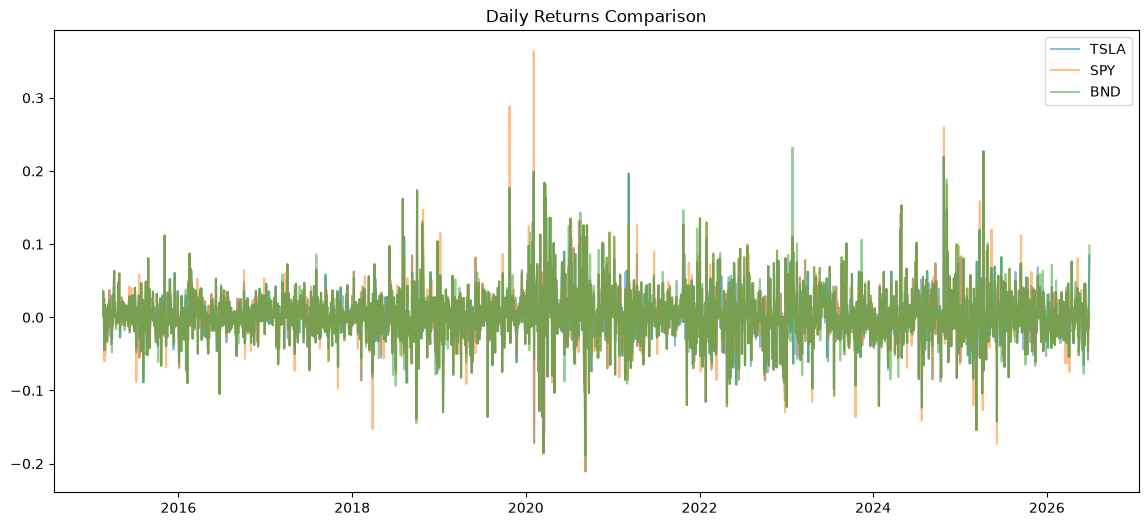

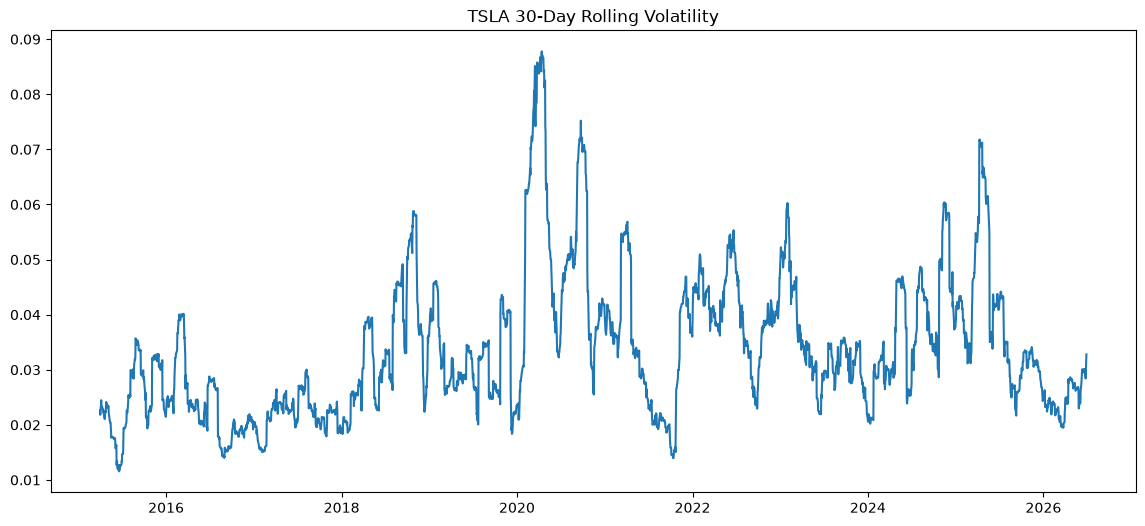

In [27]:
# Returns Analysis + Volatility Comparison
#ensure data is clean

df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
df = df.dropna()
df = df.sort_values(["Ticker", "Date"])
#compute daily return
df["Daily Return"] = df.groupby("Ticker")["Close"].pct_change()
#remove NAN rows 

df = df.dropna(subset=["Daily Return"])

#comapare return value 
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

for ticker in ["TSLA", "SPY", "BND"]:
    temp = df[df["Ticker"] == ticker]
    plt.plot(temp["Date"], temp["Daily Return"], alpha=0.5, label=ticker)

plt.title("Daily Returns Comparison")
plt.legend()
plt.show()

#roling veleocityover time 
df["Rolling Volatility"] = df.groupby("Ticker")["Daily Return"].transform(
    lambda x: x.rolling(30).std()
)

#plot TSL veleocity

tsla = df[df["Ticker"] == "TSLA"]

plt.figure(figsize=(14,6))
plt.plot(tsla["Date"], tsla["Rolling Volatility"])
plt.title("TSLA 30-Day Rolling Volatility")
plt.show()


In [45]:
#Outliers + Risk Metrics (VaR + Sharpe Ratio)
#outlier detection Zscore method

from scipy.stats import zscore

tsla = df[df["Ticker"] == "TSLA"].copy()

tsla["Z"] = zscore(tsla["Daily Return"].dropna())

tsla = tsla.dropna(subset=["Daily Return"])
tsla["Z"] = zscore(tsla["Daily Return"])
outliers = tsla[abs(tsla["Z"]) > 3]

outliers[["Date", "Close", "Daily Return", "Z"]]

# ============================================
# Outlier Detection
# ============================================

for ticker in ["TSLA", "SPY", "BND"]:

    temp = df[df["Ticker"] == ticker].copy()

    temp["Z-score"] = zscore(
        temp["Daily Return"]
    )

    outliers = temp[
        abs(temp["Z-score"]) > 3
    ]

    print(
        ticker,
        "Outliers:",
        len(outliers)
    )



TSLA Outliers: 44
SPY Outliers: 55
BND Outliers: 52


In [46]:
# ============================================
# Complete Risk Metrics var& Sharp
# ============================================

risk_free_rate = 0.02

metrics = {}

for ticker in ["TSLA", "SPY", "BND"]:

    returns = (
        df[df["Ticker"] == ticker]["Daily Return"]
        .dropna()
    )


    # Annual Return
    annual_return = (
        returns.mean() * 252
    )


    # Annual Volatility
    annual_volatility = (
        returns.std() * np.sqrt(252)
    )


    # Sharpe Ratio
    sharpe_ratio = (
        (annual_return - risk_free_rate)
        /
        annual_volatility
    )


    # Sortino Ratio
    downside = (
        returns[returns < 0]
        .std() * np.sqrt(252)
    )

    sortino_ratio = (
        (annual_return - risk_free_rate)
        /
        downside
    )


    # Maximum Drawdown

    cumulative_return = (
        1 + returns
    ).cumprod()

    rolling_peak = (
        cumulative_return
        .cummax()
    )

    drawdown = (
        cumulative_return - rolling_peak
    ) / rolling_peak


    max_drawdown = drawdown.min()


    # Value at Risk 95%

    var_95 = np.percentile(
        returns,
        5
    )


    metrics[ticker] = {

        "Annual Return": annual_return,

        "Annual Volatility": annual_volatility,

        "Sharpe Ratio": sharpe_ratio,

        "Sortino Ratio": sortino_ratio,

        "Maximum Drawdown": max_drawdown,

        "VaR 95%": var_95
    }


risk_metrics = pd.DataFrame(metrics).T


print("="*50)
print("FINAL RISK METRICS")
print("="*50)

display(
    risk_metrics.round(4)
)

FINAL RISK METRICS


,Annual Return,Annual Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,VaR 95%
TSLA,0.4647,0.5737,0.7751,1.1494,-0.7363,-0.0518
SPY,0.4610,0.5820,0.7576,1.0311,-0.7363,-0.0510
BND,0.4623,0.5710,0.7747,1.0767,-0.7363,-0.0543


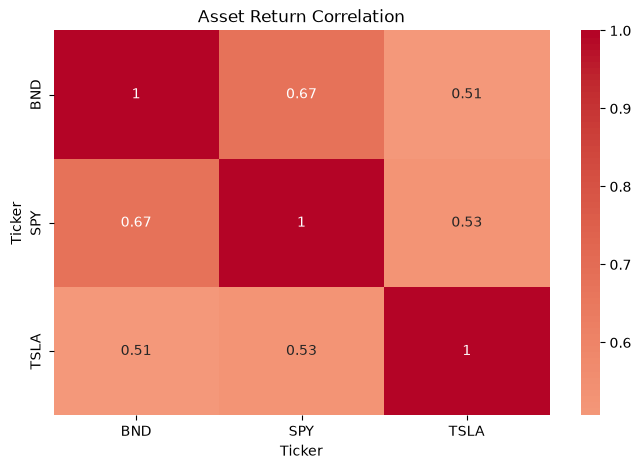

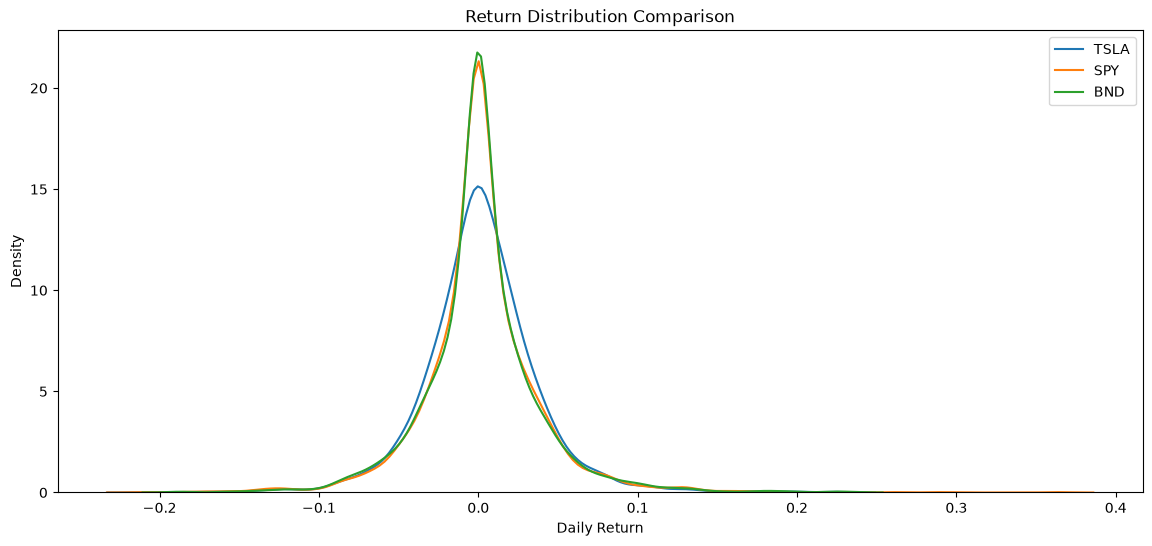

In [ ]:
#Final EDA Visualizations
#preparation and clean

returns_df = df.pivot_table(
    index="Date",
    columns="Ticker",
    values="Daily Return"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(returns_df.corr(), annot=True, cmap="coolwarm", center=0)

plt.title("Asset Return Correlation")
plt.show()


#diatribution insight
plt.figure(figsize=(14,6))

for ticker in ["TSLA", "SPY", "BND"]:
    sns.kdeplot(df[df["Ticker"] == ticker]["Daily Return"], label=ticker)

plt.title("Return Distribution Comparison")
plt.legend()
plt.show()
#rolling veleocity
plt.figure(figsize=(14,6))

for ticker in ["TSLA", "SPY", "BND"]:
    temp = df[df["Ticker"] == ticker]
    plt.plot(temp["Date"], temp["Rolling Volatility"], label=ticker)

plt.title("30-Day Rolling Volatility Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(14,6))

for ticker in ["TSLA", "SPY", "BND"]:
    temp = df[df["Ticker"] == ticker].copy()
    temp["Cumulative Return"] = (1 + temp["Daily Return"]).cumprod()

    plt.plot(temp["Date"], temp["Cumulative Return"], label=ticker)

plt.title("Cumulative Returns Over Time")
plt.legend()
plt.show()


In [ ]:
# ============================================
# ADF Stationarity Test
# ============================================

from statsmodels.tsa.stattools import adfuller

print("="*50)
print("ADF STATIONARITY TEST")
print("="*50)

for ticker in ["TSLA", "SPY", "BND"]:

    returns = (
        df[df["Ticker"] == ticker]["Daily Return"]
        .dropna()
    )

    result = adfuller(returns)

    print("\nAsset:", ticker)
    print("ADF Statistic:", round(result[0], 4))
    print("p-value:", round(result[1], 6))

    if result[1] < 0.05:
        print("Conclusion: Stationary")
    else:
        print("Conclusion: Non-stationary")

ADF STATIONARITY TEST

Asset: TSLA
ADF Statistic: -53.6839
p-value: 0.0
Conclusion: Stationary

Asset: SPY
ADF Statistic: -54.9214
p-value: 0.0
Conclusion: Stationary

Asset: BND
ADF Statistic: -52.4146
p-value: 0.0
Conclusion: Stationary
